<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/HospitalGeneral_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data & Libraries


In [14]:
from google.colab import userdata
import os

token = userdata.get('Github')
owner = "austinmallie"
repo = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Repo already cloned. Pulling latest changes...
/content/ADS599_Capstone/ADS599_Capstone
Already up to date.
/content/ADS599_Capstone


In [15]:
# Create the EDA directory if it doesn't exist
folder_name = "EDA"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [16]:
if os.path.isdir(folder_name):
    print(f"✅ Confirmation: '{folder_name}' exists at {os.getcwd()}/{folder_name}")
    print("Contents of repo:", os.listdir())
else:
    print(f"❌ Error: '{folder_name}' was not found.")

✅ Confirmation: 'EDA' exists at /content/ADS599_Capstone/EDA
Contents of repo: ['Data-Folder', 'README.md', '.git', 'correlation_matrix_high_res.png', 'EDA', 'ADS599_Capstone']


In [17]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#import data
df = pd.read_csv("Data-Folder/Hospital-Geneneral-Data/Hospital_General_Information.csv")
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


# Basic Data Information

In [19]:
#get shape
df.shape

(5426, 38)

In [20]:
#are there duplicates?
df.duplicated().sum()

np.int64(0)

In [21]:
#get datatypes
df.dtypes

,0
Facility ID,object
Facility Name,object
Address,object
City/Town,object
State,object
ZIP Code,int64
County/Parish,object
Telephone Number,object
Hospital Type,object
Hospital Ownership,object


# Basic Data Cleaning

## Organize Columns into Lists

In [22]:
provider_details = ['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code',
                    'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services',
                    'Meets criteria for birthing friendly designation']
hospital_rating = ['Hospital overall rating', 'Hospital overall rating footnote']
mort_measures = ['MORT Group Measure Count', 'Count of Facility MORT Measures',
                 'Count of MORT Measures Better', 'Count of MORT Measures No Different',
                 'Count of MORT Measures Worse', 'MORT Group Footnote']
safety_measures = ['Safety Group Measure Count', 'Count of Facility Safety Measures',
                   'Count of Safety Measures Better', 'Count of Safety Measures No Different',
                   'Count of Safety Measures Worse', 'Safety Group Footnote']
readm_measures = ['READM Group Measure Count', 'Count of Facility READM Measures',
                  'Count of READM Measures Better', 'Count of READM Measures No Different',
                  'Count of READM Measures Worse', 'READM Group Footnote'
                  ]
pt_exp_measure = ['Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnote']
te_measures = ['TE Group Measure Count', 'Count of Facility TE Measures', 'TE Group Footnote']


## Provider Details

In [23]:
df[provider_details].head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,Yes,Y
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,Yes,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,Yes,NaN


### Hospital Type

In [24]:
df['Hospital Type'].value_counts()

,count
Hospital Type,
Acute Care Hospitals,3116
Critical Access Hospitals,1376
Psychiatric,633
Acute Care - Veterans Administration,132
Childrens,94
Rural Emergency Hospital,39
Acute Care - Department of Defense,32
Long-term,4


In [25]:
#clean up hospital type groups
hospital_type_map = {
    'Acute Care Hospitals': 'Acute Care',
    'Critical Access Hospitals': 'Rural/Access',
    'Rural Emergency Hospital': 'Rural/Access',
    'Psychiatric': 'Psychiatric',
    'Childrens': 'Childrens',
    'Long-term': 'Long-term',
    'Acute Care - Veterans Administration': 'Acute Care',
    'Acute Care - Department of Defense': 'Acute Care'
}

# Apply the mapping
df['Hospital_Type'] = df['Hospital Type'].map(hospital_type_map)
print(df['Hospital_Type'].value_counts())

Hospital_Type
Acute Care      3280
Rural/Access    1415
Psychiatric      633
Childrens         94
Long-term          4
Name: count, dtype: int64


### Birthing Center

In [26]:
df['Meets criteria for birthing friendly designation'].value_counts()

,count
Meets criteria for birthing friendly designation,
Y,2265


In [27]:
#start cols to drop list
cols_to_drop = []
print(cols_to_drop)

[]


In [28]:
#rename birthing center and change to 0/1
df['Birthing_Center'] = df['Meets criteria for birthing friendly designation'].notna().astype(int)
#confirm success
pd.crosstab(df['Meets criteria for birthing friendly designation'], df['Birthing_Center'], dropna=False)
print(df.groupby('Birthing_Center')['Meets criteria for birthing friendly designation'].value_counts(dropna=False))


Birthing_Center  Meets criteria for birthing friendly designation
0                NaN                                                 3161
1                Y                                                   2265
Name: count, dtype: int64


In [29]:
cols_to_drop.append('Meets criteria for birthing friendly designation')
cols_to_drop.append('Hospital Type')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type']


### Emergency Services

In [30]:
#emergency services
df['Emergency Services'].value_counts()

,count
Emergency Services,
Yes,4499
No,927


In [31]:
# Map 'yes' to 1 and 'no' to 0
df['Emergency_Services'] = df['Emergency Services'].map({'Yes': 1, 'No': 0})
#confirm success
pd.crosstab(df['Emergency Services'], df['Emergency_Services'], dropna=False)
print(df.groupby('Emergency_Services')['Emergency Services'].value_counts(dropna=False))


Emergency_Services  Emergency Services
0                   No                     927
1                   Yes                   4499
Name: count, dtype: int64


In [32]:
cols_to_drop.append('Emergency Services')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services']


### Hospital Ownership

In [33]:
df['Hospital Ownership'].value_counts()

,count
Hospital Ownership,
Voluntary non-profit - Private,2304
Proprietary,1069
Government - Hospital District or Authority,519
Government - Local,401
Voluntary non-profit - Other,355
Voluntary non-profit - Church,271
Government - State,209
Veterans Health Administration,132
Physician,76


In [34]:
#Map the types of hospitals to three categories
ownership_map = {
    'Voluntary non-profit - Private': 'Non-Profit',
    'Voluntary non-profit - Other': 'Non-Profit',
    'Voluntary non-profit - Church': 'Non-Profit',
    'Proprietary': 'For-Profit',
    'Physician': 'For-Profit',
    'Government - Hospital District or Authority': 'Government',
    'Government - Local': 'Government',
    'Government - State': 'Government',
    'Government - Federal': 'Government',
    'Veterans Health Administration': 'Government',
    'Department of Defense': 'Government',
    'Tribal': 'Government'
}

In [35]:
# Create the new column
df['Hospital_Ownership'] = df['Hospital Ownership'].map(ownership_map)
#confirm success
pd.crosstab(df['Hospital Ownership'], df['Hospital_Ownership'], dropna=False)
print(df.groupby('Hospital_Ownership')['Hospital Ownership'].value_counts(dropna=False))

Hospital_Ownership  Hospital Ownership                         
For-Profit          Proprietary                                    1069
                    Physician                                        76
Government          Government - Hospital District or Authority     519
                    Government - Local                              401
                    Government - State                              209
                    Veterans Health Administration                  132
                    Government - Federal                             43
                    Department of Defense                            32
                    Tribal                                           15
Non-Profit          Voluntary non-profit - Private                 2304
                    Voluntary non-profit - Other                    355
                    Voluntary non-profit - Church                   271
Name: count, dtype: int64


In [36]:
cols_to_drop.append('Hospital Ownership')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership']


## Hospital Rating

In [37]:
df[hospital_rating].head()

,Hospital overall rating,Hospital overall rating footnote
0,4,NaN
1,3,NaN
2,2,NaN
3,1,NaN
4,Not Available,16


In [38]:
df['Hospital overall rating'].value_counts()

,count
Hospital overall rating,
Not Available,2560
3,935
4,765
2,649
5,288
1,229


In [39]:
df['Hospital_Rating'] = pd.to_numeric(df['Hospital overall rating'], errors='coerce')
#confirm success
pd.crosstab(df['Hospital overall rating'], df['Hospital_Rating'], dropna=False, margins = True)
print(df.groupby('Hospital_Rating')['Hospital overall rating'].value_counts(dropna=False))

Hospital_Rating  Hospital overall rating
1.0              1                          229
2.0              2                          649
3.0              3                          935
4.0              4                          765
5.0              5                          288
Name: count, dtype: int64


In [40]:
df['Hospital overall rating footnote'].value_counts()

,count
Hospital overall rating footnote,
16,1672
19,800
5,54
22,32
17,7
23,5
"16, 23",2


In [41]:
cols_to_drop.append('Hospital overall rating footnote')
cols_to_drop.append('Hospital overall rating')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating']


## Mort Measures

In [42]:
df[mort_measures].head()

,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,MORT Group Footnote
0,7,7,0,7,0,NaN
1,7,6,0,5,1,NaN
2,7,7,0,5,2,NaN
3,7,3,0,2,1,NaN
4,7,1,0,1,0,NaN


In [43]:
df['MORT Group Measure Count'].value_counts()

,count
MORT Group Measure Count,
7,4551
Not Available,875


In [44]:
df['Count of Facility MORT Measures'].value_counts()

,count
Count of Facility MORT Measures,
Not Available,1786
7,850
6,587
1,493
5,455
3,442
2,421
4,392


In [45]:
cols_to_drop.append('MORT Group Measure Count')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count']


In [46]:
df['Count of MORT Measures Better'].value_counts()

,count
Count of MORT Measures Better,
0,3132
Not Available,1786
1,297
2,133
3,53
4,15
5,7
7,2
6,1


### Mort Group Footnote


*  5.0: Not Available for reporting period
*  19.0: Not Available / Not Participating
*  22.0: Not Applicable
*  23.0: Data Surpressed

In [47]:
df['MORT Group Footnote'].value_counts()

,count
MORT Group Footnote,
5.0,954
19.0,800
22.0,32
23.0,1


In [48]:
cols_to_drop.append('MORT Group Footnote')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count', 'MORT Group Footnote']


## Safety Measures

In [49]:
df[safety_measures].head()

,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,Safety Group Footnote
0,8,7,3,4,0,NaN
1,8,7,0,7,0,NaN
2,8,8,3,5,0,NaN
3,8,3,0,3,0,NaN
4,8,Not Available,Not Available,Not Available,Not Available,5


In [50]:
cols_to_drop.append('Safety Group Measure Count')
cols_to_drop.append('Safety Group Footnote')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count', 'MORT Group Footnote', 'Safety Group Measure Count', 'Safety Group Footnote']


## Readm Measures

In [51]:
df[readm_measures].head()

,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote
0,11,11,0,11,0,NaN
1,11,9,0,8,1,NaN
2,11,9,0,8,1,NaN
3,11,7,0,7,0,NaN
4,11,2,0,2,0,NaN


In [52]:
df['READM Group Measure Count'].value_counts()

,count
READM Group Measure Count,
11,4551
Not Available,875


In [53]:
df['READM Group Footnote'].value_counts()

,count
READM Group Footnote,
19.0,800
5.0,328
22.0,32


In [54]:
cols_to_drop.append('READM Group Measure Count')
cols_to_drop.append('READM Group Footnote')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count', 'MORT Group Footnote', 'Safety Group Measure Count', 'Safety Group Footnote', 'READM Group Measure Count', 'READM Group Footnote']


## Patient Experience Measures

In [55]:
df[pt_exp_measure].head()

,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote
0,8,8,NaN
1,8,8,NaN
2,8,8,NaN
3,8,8,NaN
4,8,Not Available,5.0


In [56]:
df['Pt Exp Group Measure Count'].value_counts()

,count
Pt Exp Group Measure Count,
8,4551
Not Available,875


In [57]:
cols_to_drop.append('Pt Exp Group Measure Count')
cols_to_drop.append('Pt Exp Group Footnote')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count', 'MORT Group Footnote', 'Safety Group Measure Count', 'Safety Group Footnote', 'READM Group Measure Count', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Pt Exp Group Footnote']


## TE Measures

In [58]:
df[te_measures].head()

,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,12,11,NaN
1,12,12,NaN
2,12,10,NaN
3,12,7,NaN
4,12,6,NaN


In [59]:
df['TE Group Measure Count'].value_counts()

,count
TE Group Measure Count,
12,4551
Not Available,875


In [60]:
cols_to_drop.append('TE Group Measure Count')
cols_to_drop.append('TE Group Footnote')
print(cols_to_drop)

['Meets criteria for birthing friendly designation', 'Hospital Type', 'Emergency Services', 'Hospital Ownership', 'Hospital overall rating footnote', 'Hospital overall rating', 'MORT Group Measure Count', 'MORT Group Footnote', 'Safety Group Measure Count', 'Safety Group Footnote', 'READM Group Measure Count', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Pt Exp Group Footnote', 'TE Group Measure Count', 'TE Group Footnote']


## Drop Columns

In [61]:
df = df.drop(columns=cols_to_drop)
df.shape

(5426, 27)

## Adjust Datatypes

In [62]:
df.dtypes

,0
Facility ID,object
Facility Name,object
Address,object
City/Town,object
State,object
ZIP Code,int64
County/Parish,object
Telephone Number,object
Count of Facility MORT Measures,object
Count of MORT Measures Better,object


In [63]:
#convert count columns to numeric
count_cols = [
    "Count of Facility MORT Measures",
    "Count of MORT Measures Better",
    "Count of MORT Measures No Different",
    "Count of MORT Measures Worse",
    "Count of Facility Safety Measures",
    "Count of Safety Measures Better",
    "Count of Safety Measures No Different",
    "Count of Safety Measures Worse",
    "Count of Facility READM Measures",
    "Count of READM Measures Better",
    "Count of READM Measures No Different",
    "Count of READM Measures Worse",
    "Count of Facility Pt Exp Measures",
    "Count of Facility TE Measures"
]

for col in count_cols:
    if col in df.columns:
        # Convert to numeric, turning 'Not Available' into NaN
        df[col] = pd.to_numeric(df[col].replace('Not Available', np.nan), errors='coerce')
    else:
        print(f"Warning: '{col}' was not found in your DataFrame columns.")

In [64]:
#confirm if data dropped leading zeros on zips
short_zips = df[df['ZIP Code'] < 10000]
print(short_zips['ZIP Code'].head())

798    6105
799    6260
800    6069
801    6721
802    6904
Name: ZIP Code, dtype: int64


In [65]:
df['ZIP Code'] =df['ZIP Code'] .astype(str).str.zfill(5)
# Check how many ZIP codes have 5 characters
print((df['ZIP Code'].str.len() == 5).value_counts())

ZIP Code
True    5426
Name: count, dtype: int64


In [66]:
df.dtypes

,0
Facility ID,object
Facility Name,object
Address,object
City/Town,object
State,object
ZIP Code,object
County/Parish,object
Telephone Number,object
Count of Facility MORT Measures,float64
Count of MORT Measures Better,float64


# Data Quality Report

## Missing Data

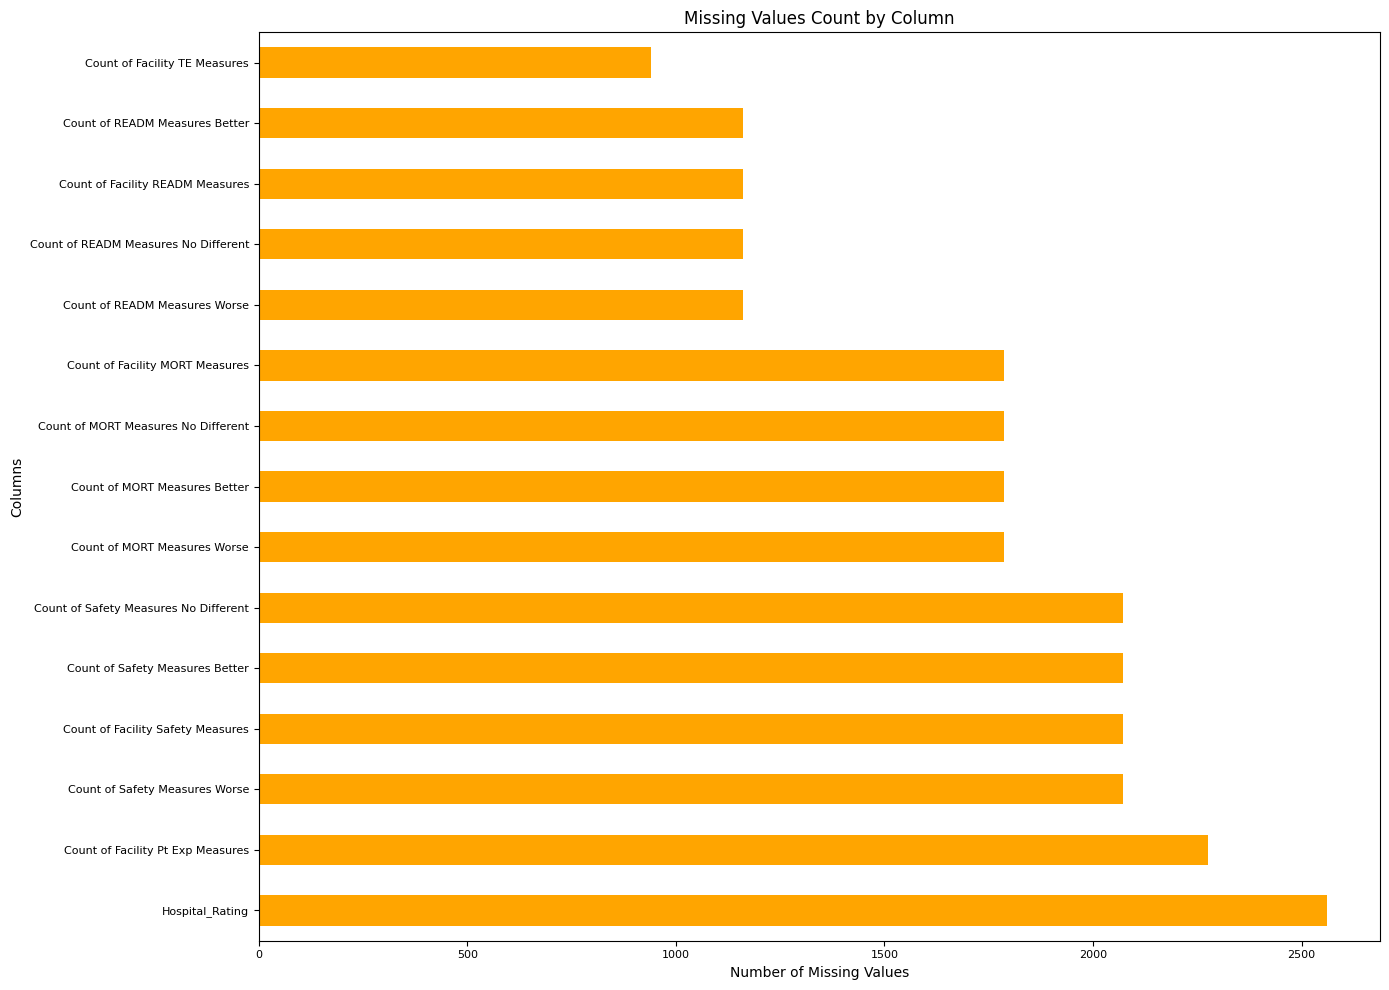

In [67]:
#missing visualization
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)

plt.figure(figsize=(14, 10))
missing_values.plot(kind='barh', color='orange')
plt.title('Missing Values Count by Column', fontsize=12)
plt.xlabel('Number of Missing Values', fontsize=10)
plt.ylabel('Columns', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

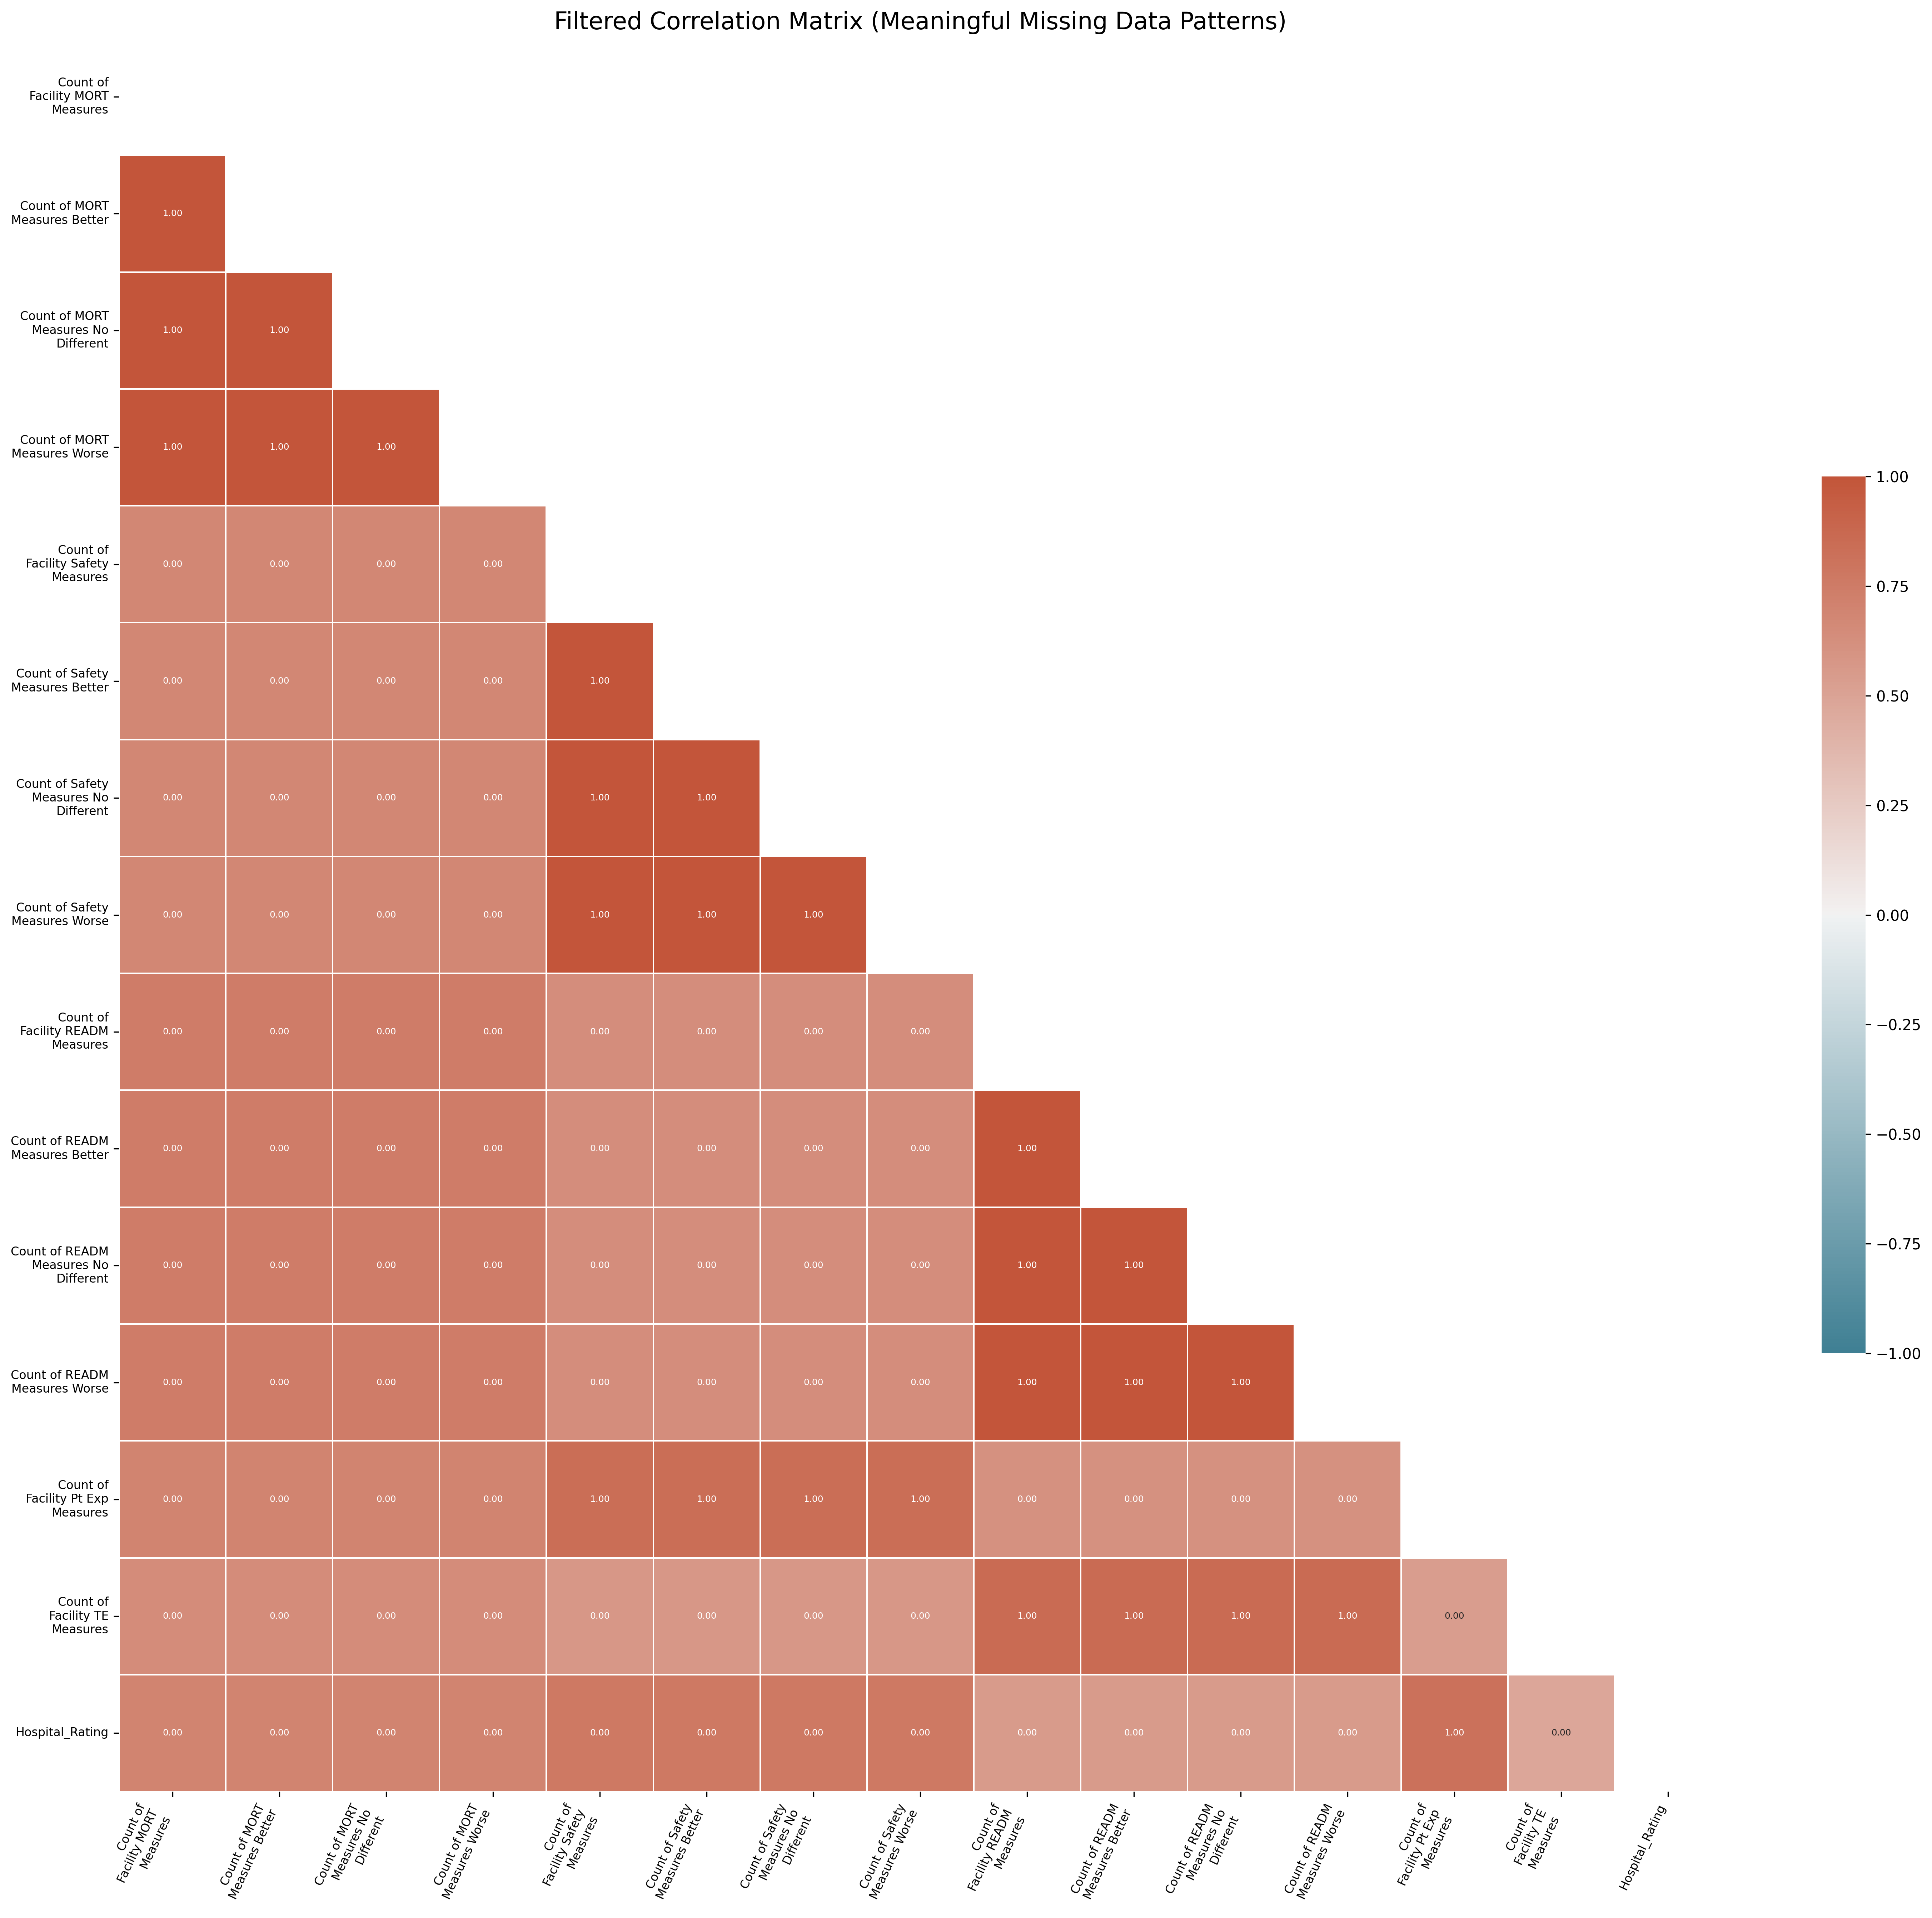

In [68]:
import textwrap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#code source: #code source: https://medium.com/@HildaPosada/finding-and-visualizing-missing-data-in-python-using-missingno-and-seaborn-d4cf0452b9e9
#gemini used to assist in filtering to meaningful results only
# 1. Compute correlation
corr_matrix = df.isnull().corr()

# 2. FILTERING LOGIC: Keep columns that have at least one correlation > 0.5 with another variable
# This removes columns that don't share missingness patterns with anything else
mask_meaningful = (corr_matrix.abs() > 0.5).any()
corr_filtered = corr_matrix.loc[mask_meaningful, mask_meaningful]

# 3. Use the filtered matrix for the rest of your logic
threshold = 0.8
mask_values = np.abs(corr_filtered) >= threshold

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_filtered, dtype=bool))

# Customize the color palette
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Set up the figure
plt.figure(figsize=(20, 18), dpi=300)

# Create the heatmap using the FILTERED matrix
sns.heatmap(corr_filtered, mask=mask, cmap=cmap, annot=mask_values, fmt=".2f",
            linewidths=.5, cbar_kws={"shrink": 0.5}, vmin=-1, vmax=1,
            annot_kws={"size": 6}) # Increased size slightly for visibility

# Wrap labels for the filtered columns
wrapped_columns = [textwrap.fill(col, 15) for col in corr_filtered.columns]

# Set axis labels
plt.xticks(np.arange(len(wrapped_columns)) + 0.5, wrapped_columns, rotation=65, ha='right', fontsize=8)
plt.yticks(np.arange(len(wrapped_columns)) + 0.5, wrapped_columns, fontsize=8)

plt.title('Filtered Correlation Matrix (Meaningful Missing Data Patterns)', fontsize=16)
plt.tight_layout()
plt.show()

## Continuous Features

In [69]:
# identify continuous features
conf = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
conf

['Count of Facility MORT Measures',
 'Count of MORT Measures Better',
 'Count of MORT Measures No Different',
 'Count of MORT Measures Worse',
 'Count of Facility Safety Measures',
 'Count of Safety Measures Better',
 'Count of Safety Measures No Different',
 'Count of Safety Measures Worse',
 'Count of Facility READM Measures',
 'Count of READM Measures Better',
 'Count of READM Measures No Different',
 'Count of READM Measures Worse',
 'Count of Facility Pt Exp Measures',
 'Count of Facility TE Measures',
 'Birthing_Center',
 'Emergency_Services',
 'Hospital_Rating']

In [70]:
data_quality_conf = pd.DataFrame({
    'Feature': conf,
    'Count': df[conf].count().values,
    'Missing Values': df[conf].isnull().sum().values,
    'Cardinality': df[conf].nunique().values,
    'Min': df[conf].min().values,
    'Max': df[conf].max().values,
})
data_quality_conf

,Feature,Count,Missing Values,Cardinality,Min,Max
0,Count of Facility MORT Measures,3640,1786,7,1.0,7.0
1,Count of MORT Measures Better,3640,1786,8,0.0,7.0
2,Count of MORT Measures No Different,3640,1786,8,0.0,7.0
3,Count of MORT Measures Worse,3640,1786,6,0.0,5.0
4,Count of Facility Safety Measures,3353,2073,8,1.0,8.0
5,Count of Safety Measures Better,3353,2073,7,0.0,6.0
6,Count of Safety Measures No Different,3353,2073,9,0.0,8.0
7,Count of Safety Measures Worse,3353,2073,4,0.0,3.0
8,Count of Facility READM Measures,4266,1160,11,1.0,11.0
9,Count of READM Measures Better,4266,1160,6,0.0,5.0


## Categorical Features

In [71]:
#identify any categorical features
catf = df.select_dtypes(include=['object']).columns.tolist()
catf

['Facility ID',
 'Facility Name',
 'Address',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Telephone Number',
 'Hospital_Type',
 'Hospital_Ownership']

In [72]:
#see missing
missing_counts = df[catf].isnull().sum()
print(missing_counts)

Facility ID           0
Facility Name         0
Address               0
City/Town             0
State                 0
ZIP Code              0
County/Parish         0
Telephone Number      0
Hospital_Type         0
Hospital_Ownership    0
dtype: int64


In [73]:
#identify any columns to filter out from the "categorical features"
catf_exclude = ['Facility ID','Facility Name', 'Address', 'City/Town', 'ZIP Code', 'Telephone Number']
filter_catf = [x for x in catf if x not in catf_exclude]
filter_catf

['State', 'County/Parish', 'Hospital_Type', 'Hospital_Ownership']

In [74]:
#create lists to store modes & frequencies
modes = []
mode_freqs = []
second_modes = []
second_mode_freqs = []
mode_percentages = []
second_mode_percentages = []

In [75]:
# Calculate mode and frequency for each categorical feature
for feature in filter_catf:
    count = df[feature].count()
    mode = df[feature].mode().iloc[0]
    mode_freq = df[feature].value_counts().iloc[0]
    modes.append(mode)
    mode_freqs.append(mode_freq)
    mode_percentages.append((mode_freq / count) * 100 if count > 0 else 0)

    # Calculate second mode and its frequency
    if len(df[feature].value_counts()) > 1:
        second_mode = df[feature].value_counts().index[1]
        second_mode_freq = df[feature].value_counts().iloc[1]
    else:
        second_mode = None
        second_mode_freq = 0

    second_modes.append(second_mode)
    second_mode_freqs.append(second_mode_freq)
    second_mode_percentages.append((second_mode_freq / count) * 100 if count > 0 else 0)

In [76]:
# Get unique values and counts
cat_count = df[filter_catf].value_counts(ascending = False)

In [74]:
#build quality report table
data_quality_catf = pd.DataFrame({
    'Feature': filter_catf,
    'Count': df[filter_catf].count().values,
    'Missing Values': df[filter_catf].isnull().sum().values,
    'Cardinality': df[filter_catf].nunique().values,
    'Mode':modes,
    'Mode Frequency':mode_freqs,
    'Mode %': mode_percentages,
    '2nd Mode':second_modes,
    '2nd Mode Frequency': second_mode_freqs,
    '2nd Mode %': second_mode_percentages,
})
data_quality_catf

,Feature,Count,Missing Values,Cardinality,Mode,Mode Frequency,Mode %,2nd Mode,2nd Mode Frequency,2nd Mode %
0,State,5426,0,56,TX,465,8.569849,CA,378,6.966458
1,County/Parish,5426,0,1555,LOS ANGELES,88,1.621821,COOK,59,1.087357
2,Hospital Type,5426,0,8,Acute Care Hospitals,3116,57.427202,Critical Access Hospitals,1376,25.359381
3,Hospital_Ownership,5426,0,3,Non-Profit,2930,53.999263,Government,1351,24.898636


# Univariate Analysis

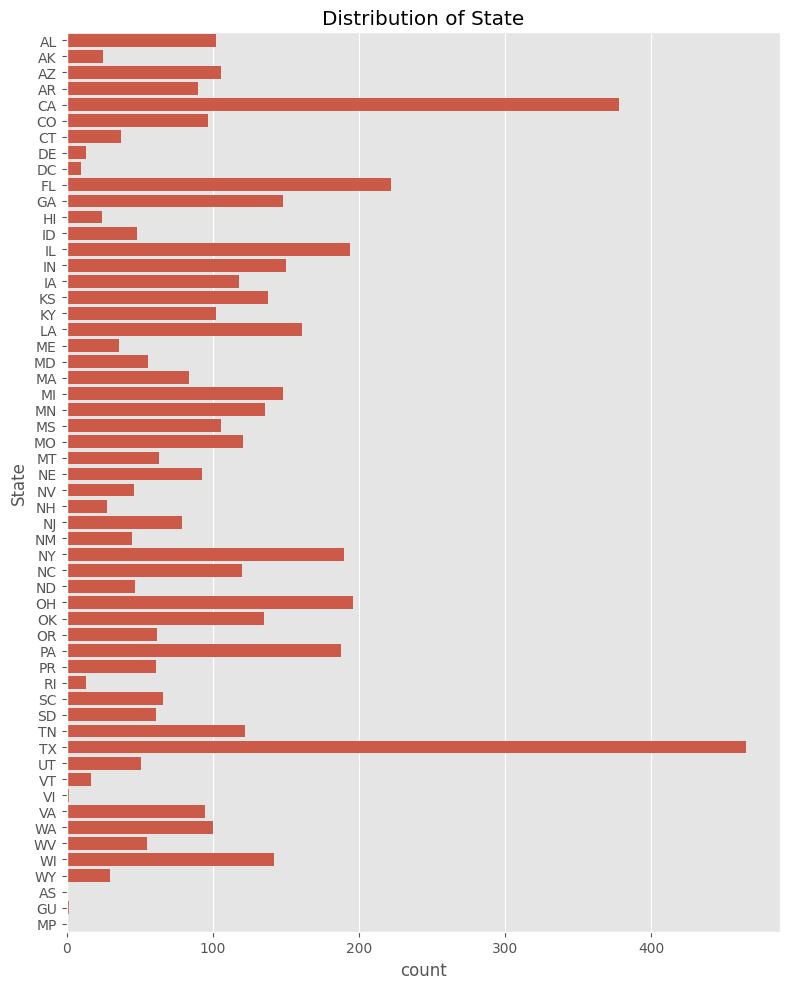

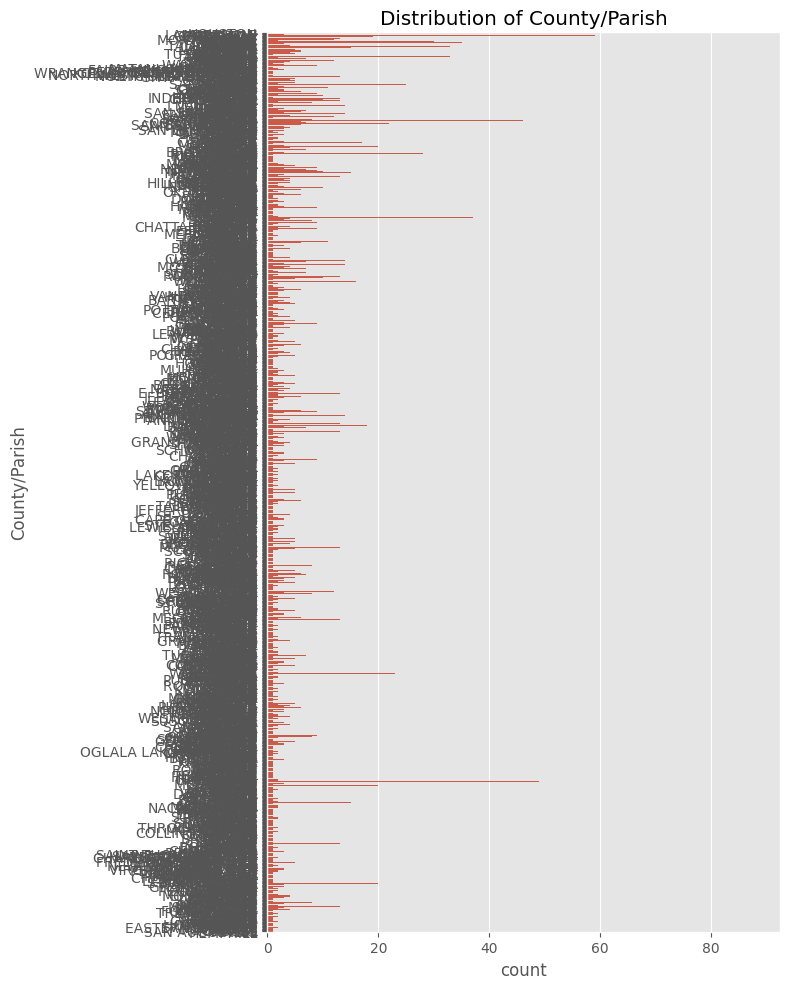

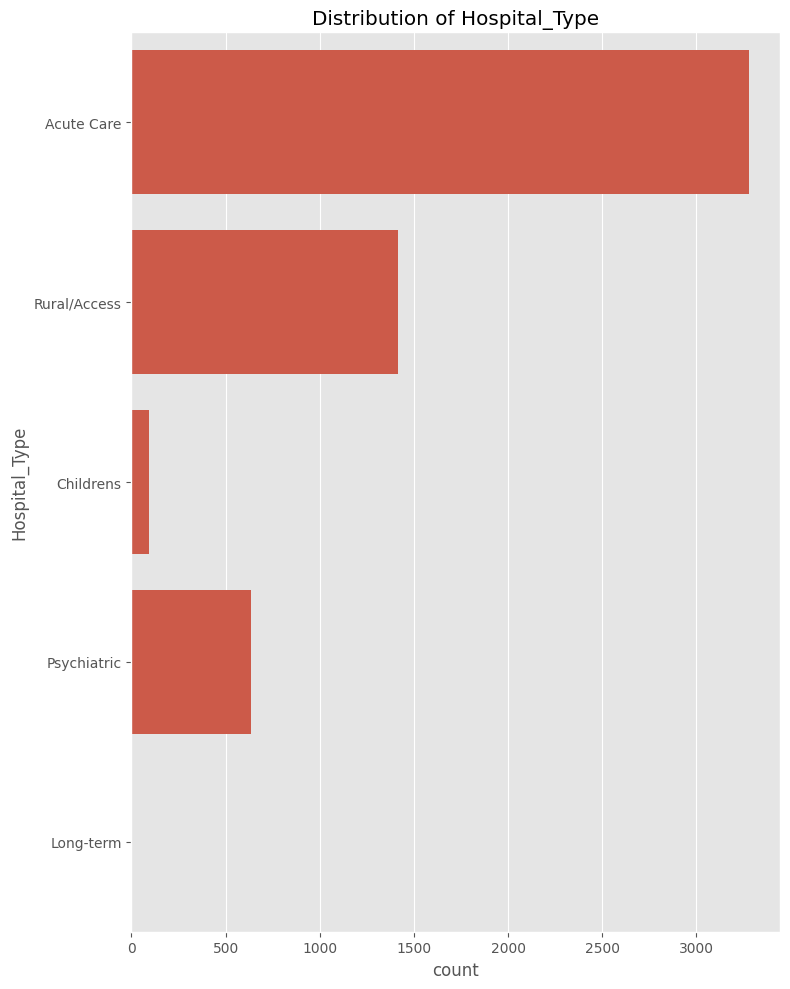

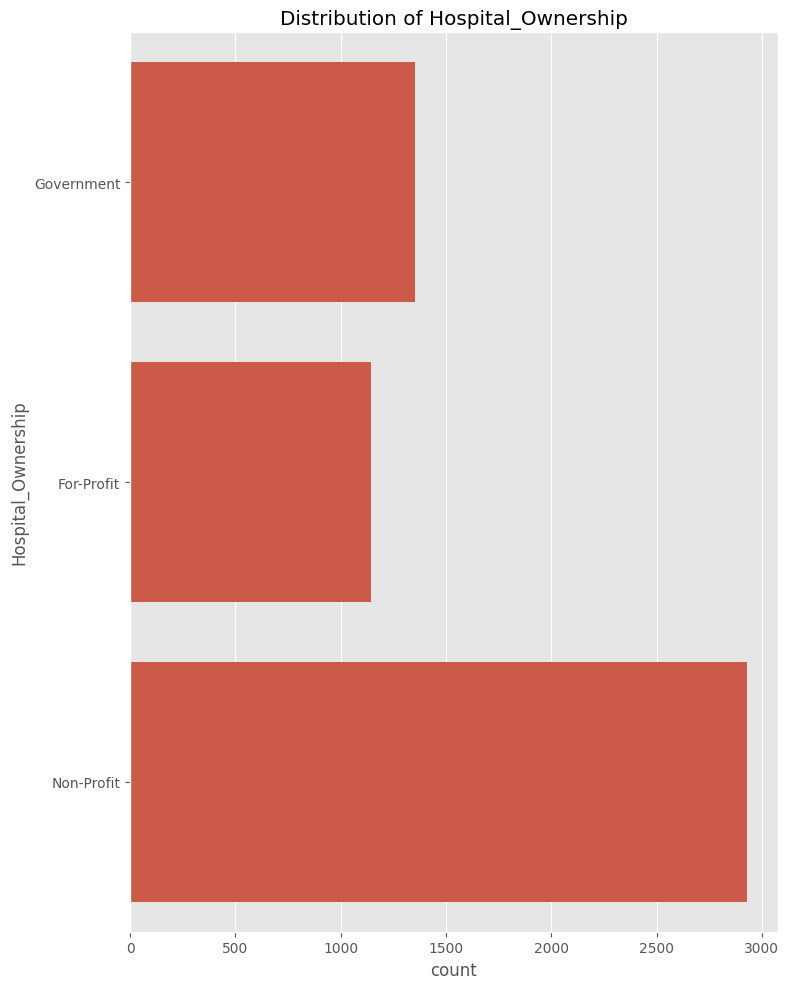

In [77]:
#plot the categorical variables
plt.style.use('ggplot')

for column in filter_catf:
    plt.figure(figsize=(8, 10))
    sns.countplot(y=column, data=df)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

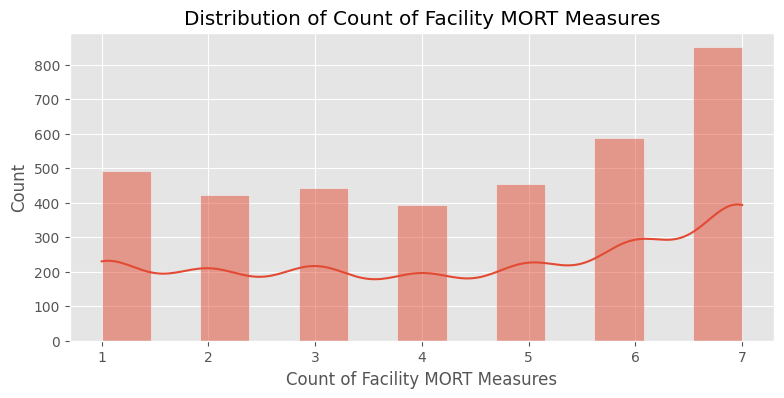

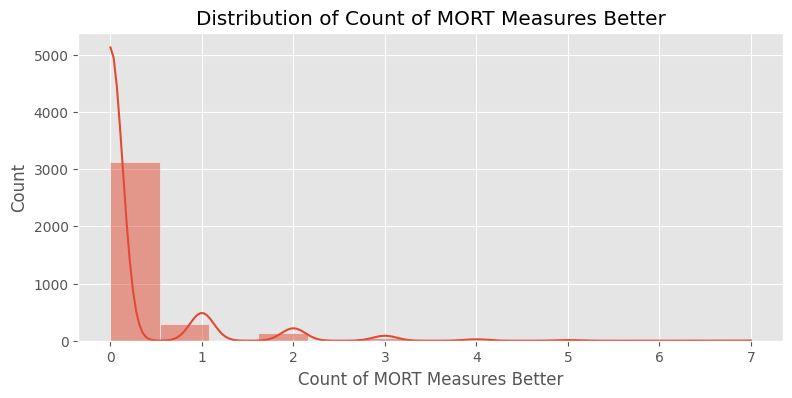

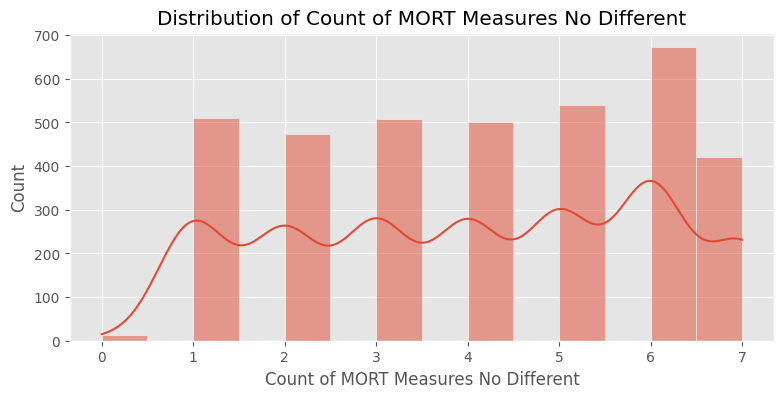

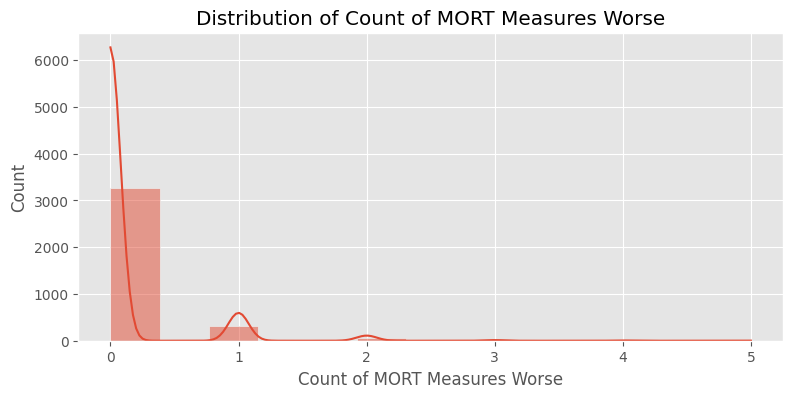

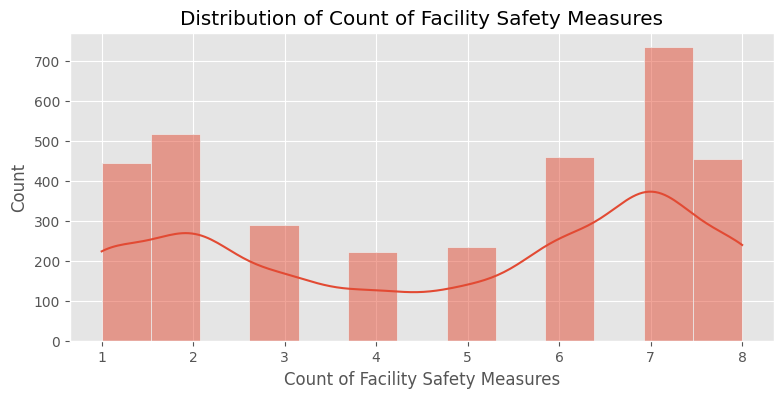

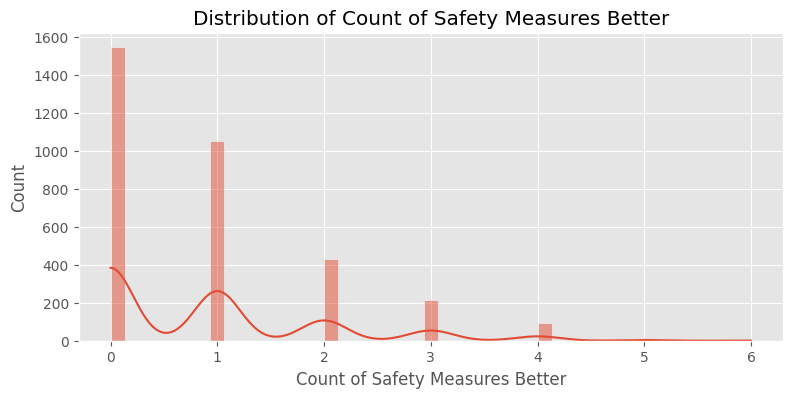

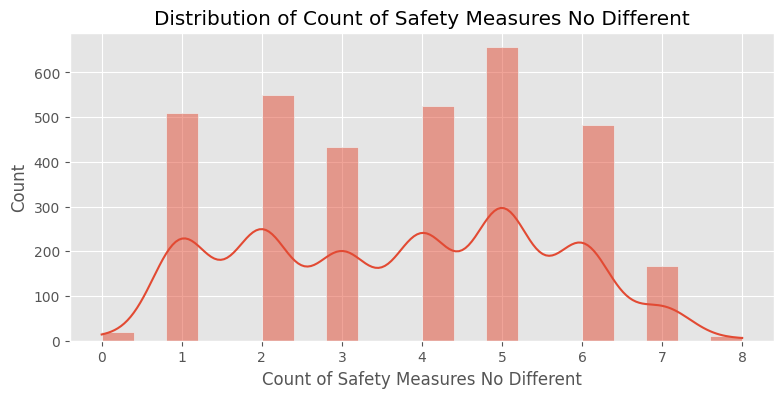

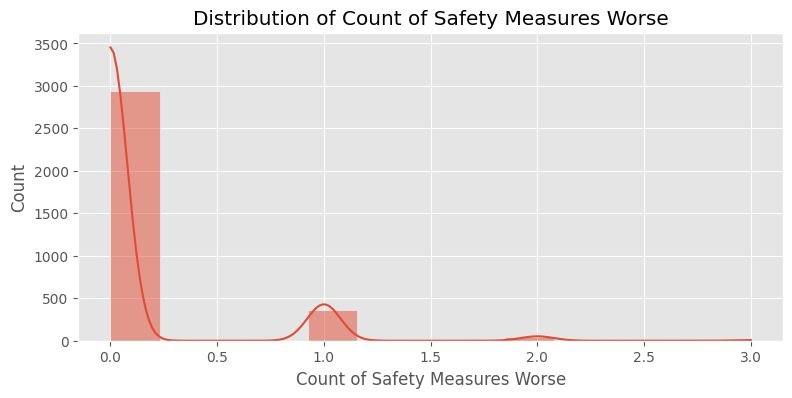

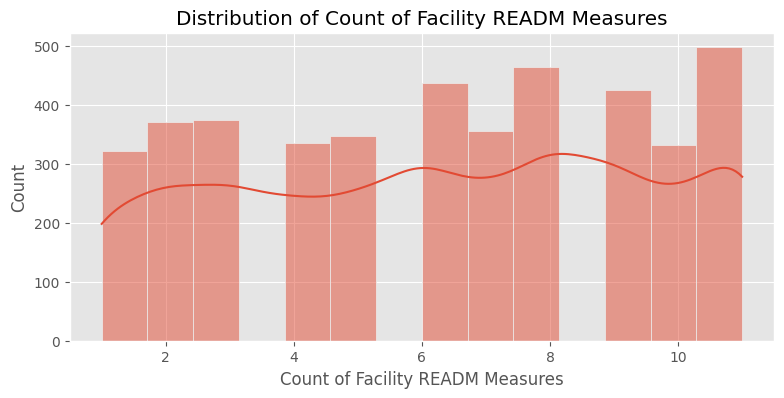

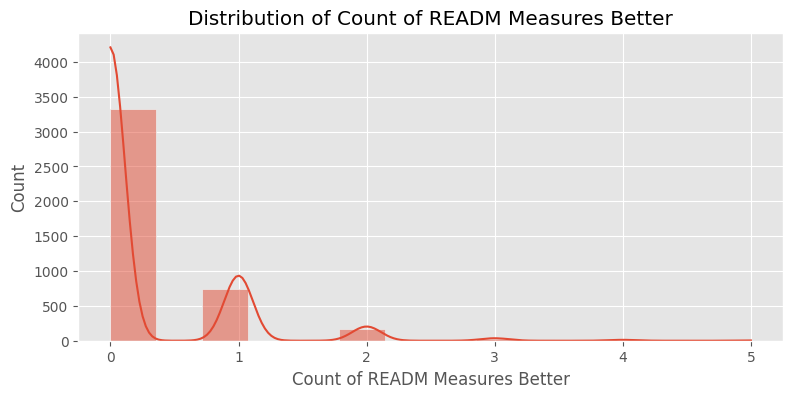

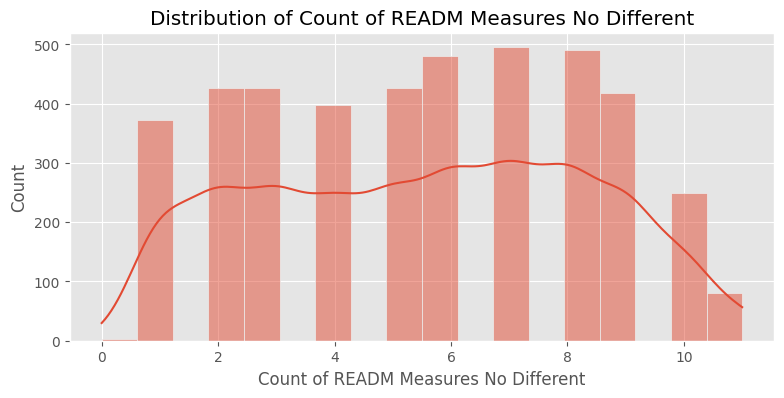

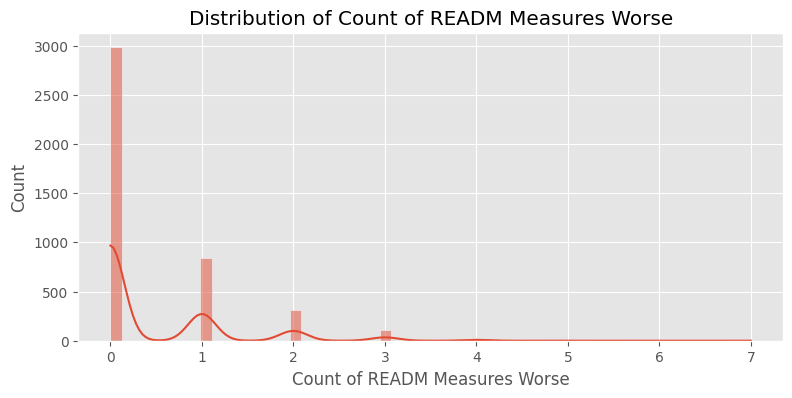

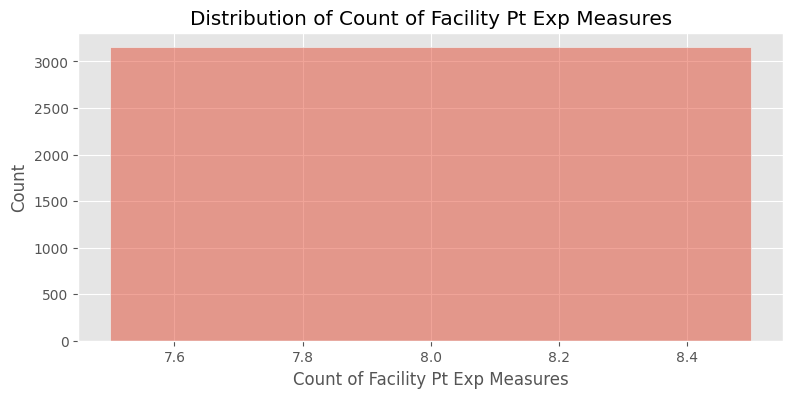

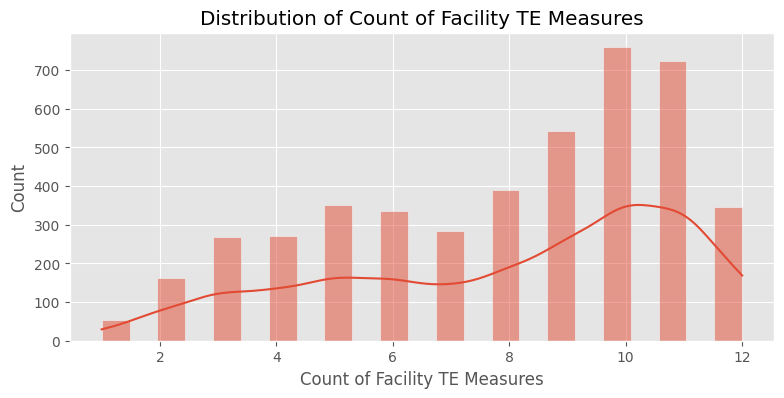

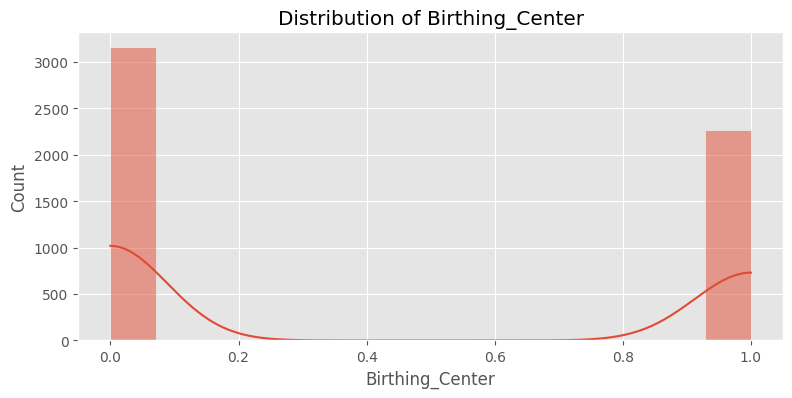

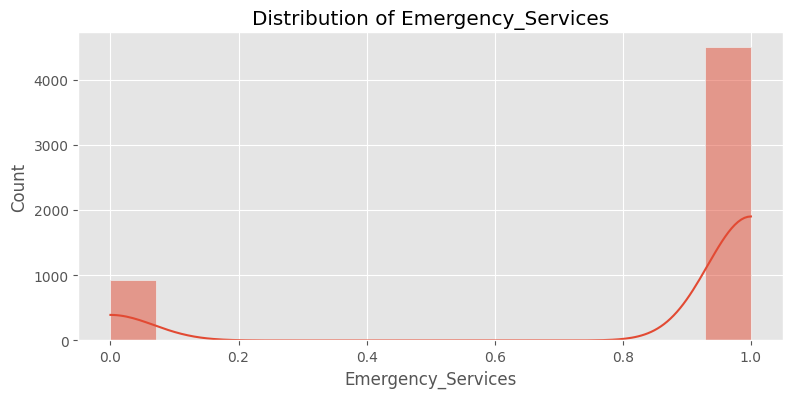

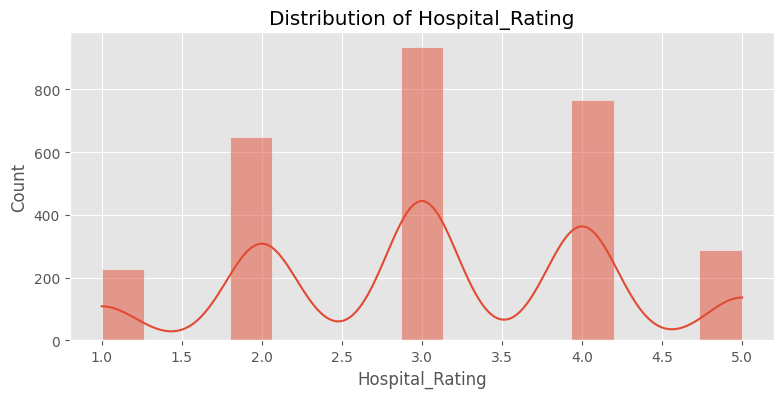

In [79]:
#plot histograms for numerical variables
plt.style.use('ggplot')
for column in conf:
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde = True)
    plt.title(f'Distribution of {column}')
    plt.show()

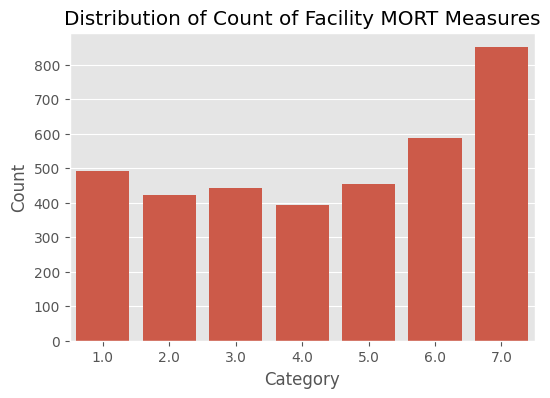

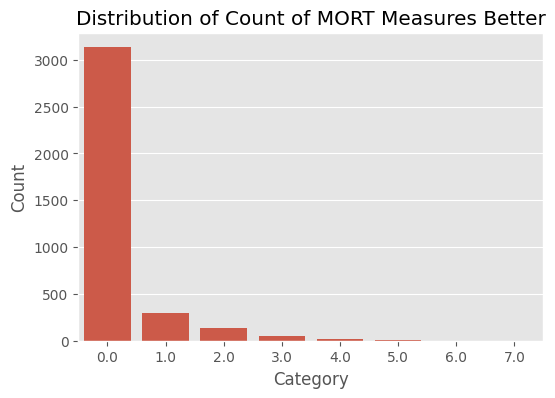

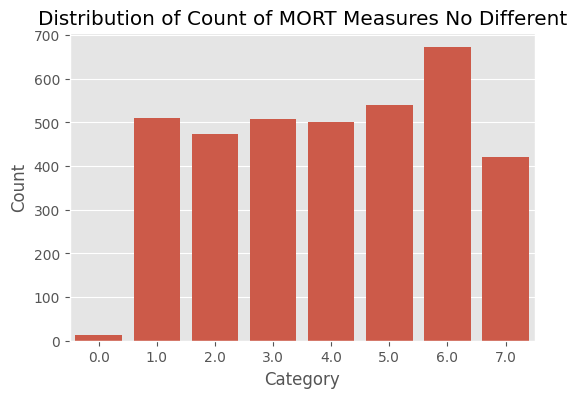

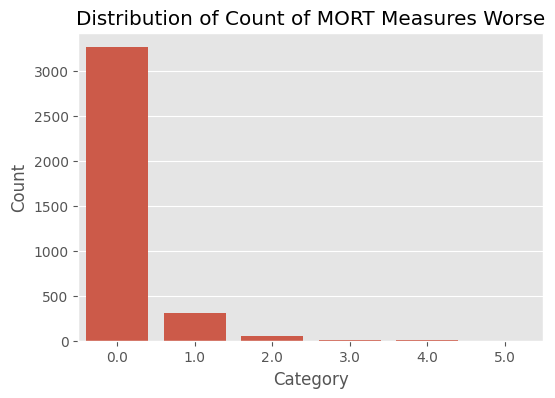

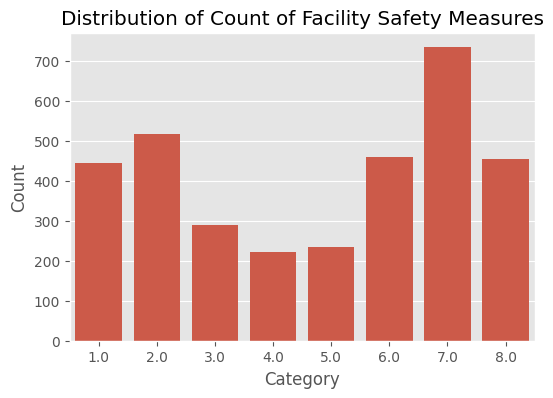

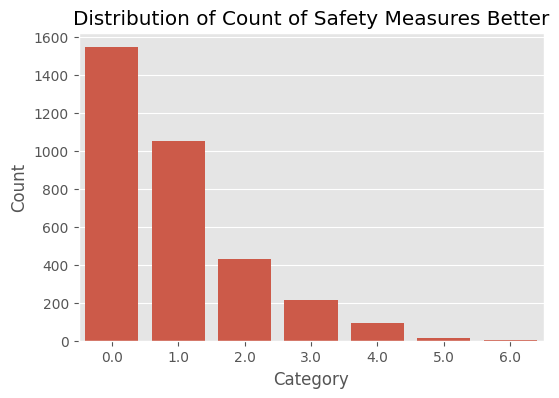

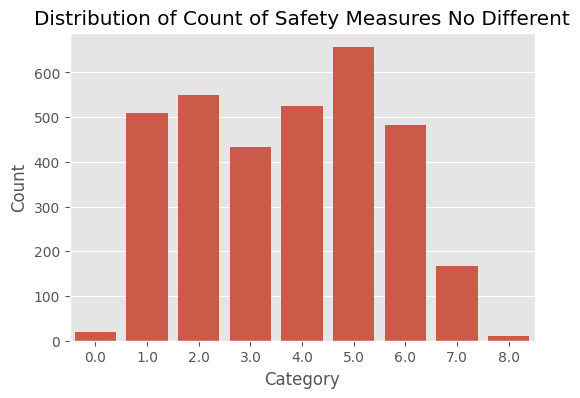

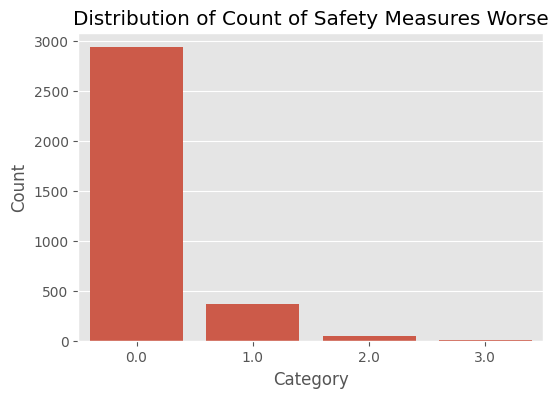

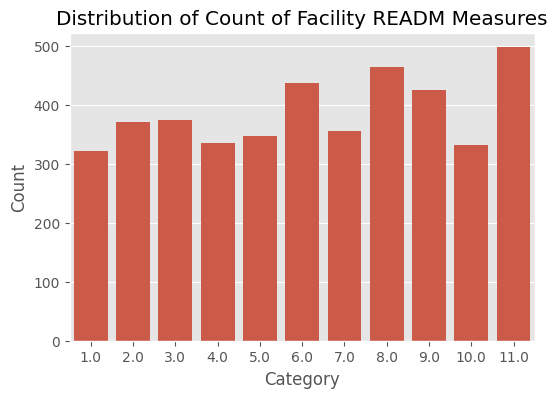

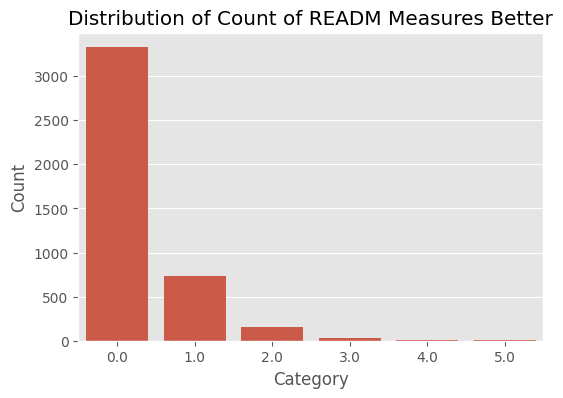

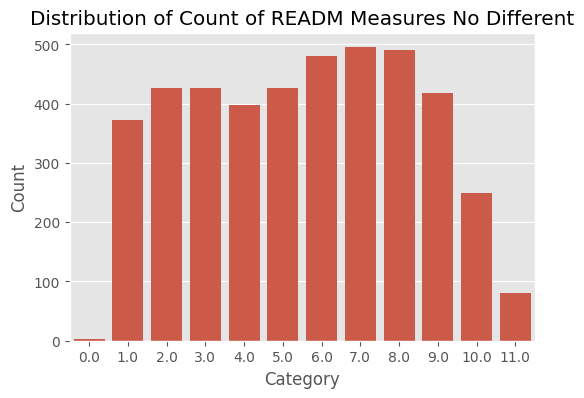

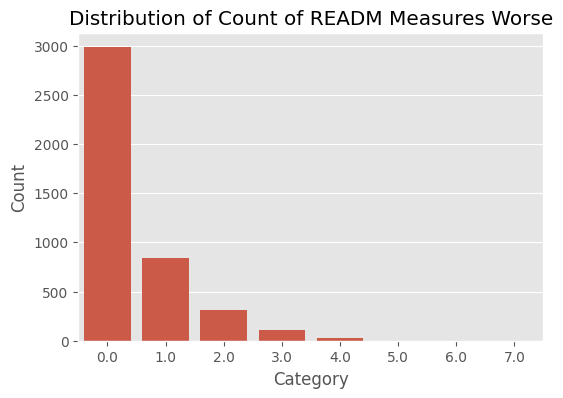

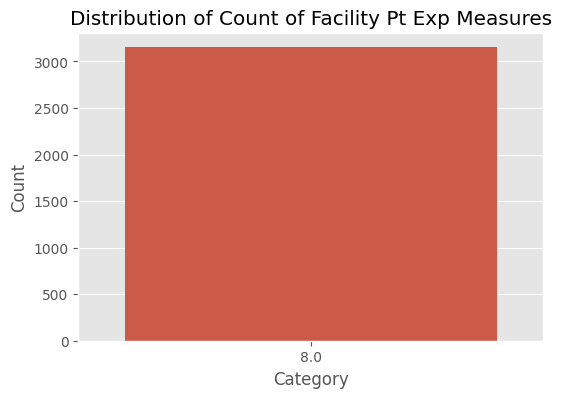

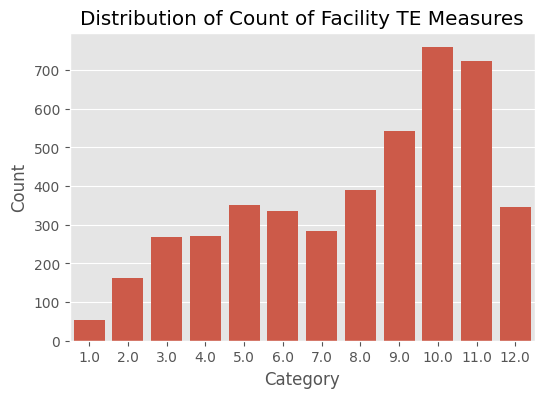

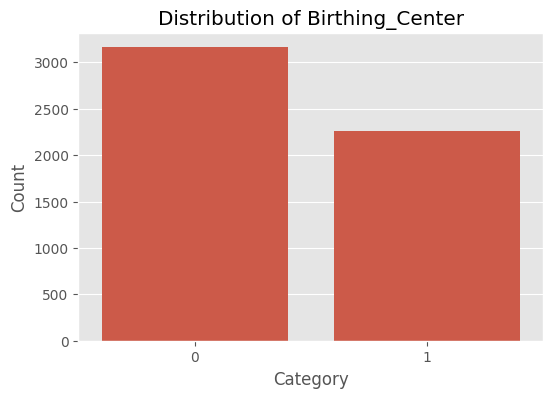

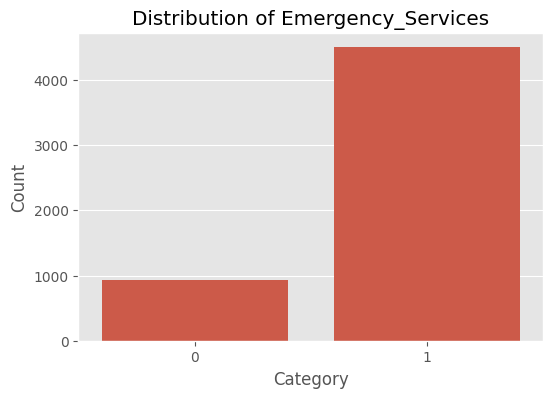

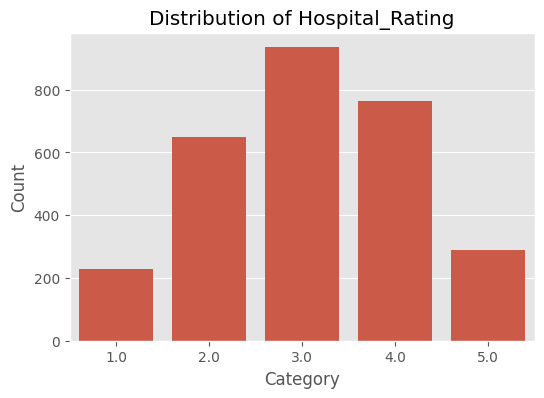

In [80]:
plt.style.use('ggplot')

for column in conf:
    plt.figure(figsize=(6, 4))

    # Use countplot for categorical/binary data
    sns.countplot(x=column, data=df)

    plt.title(f'Distribution of {column}')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.show()

# Multivariate Analysis

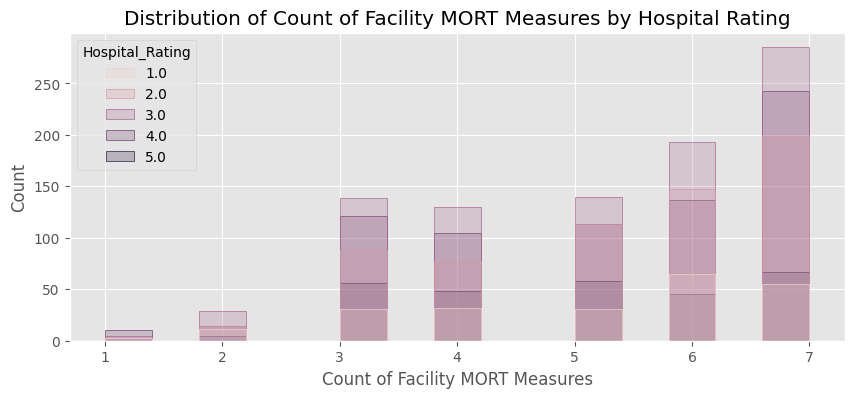

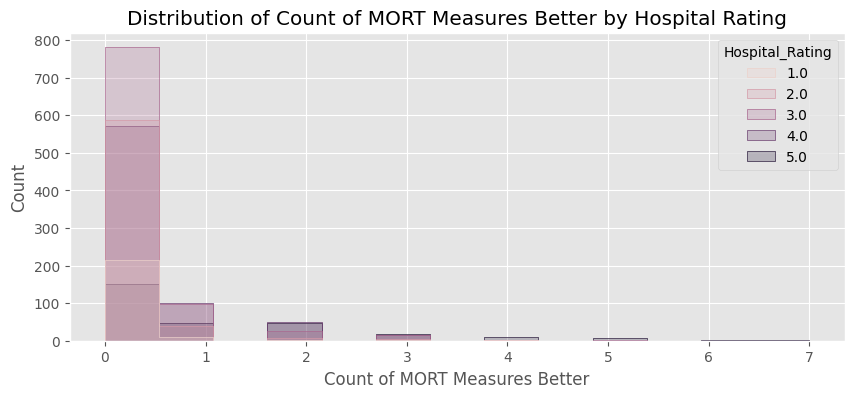

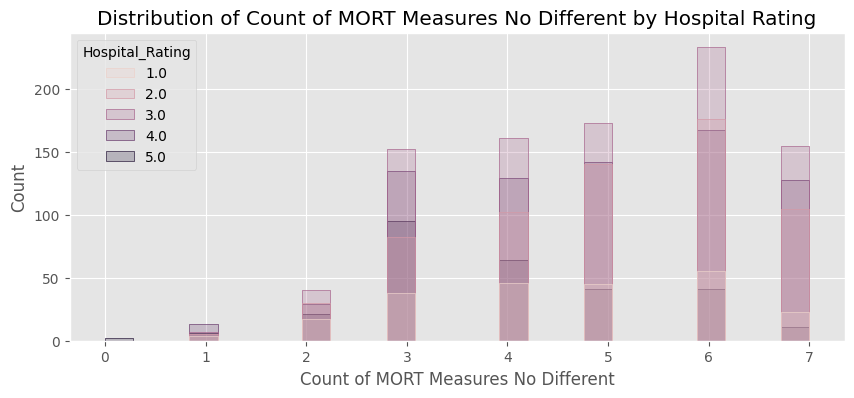

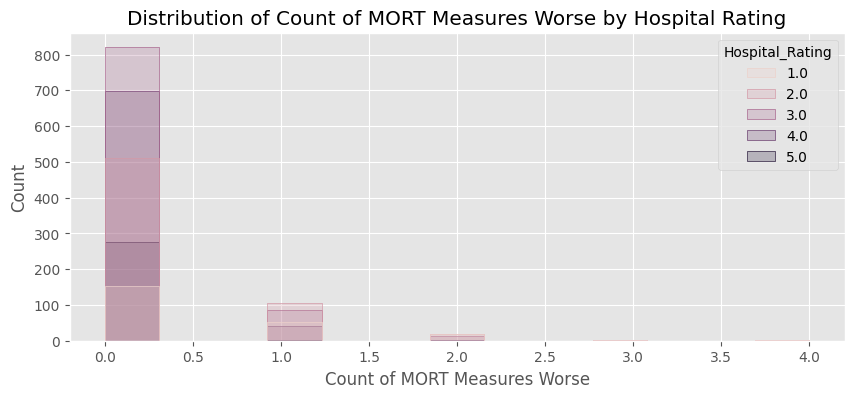

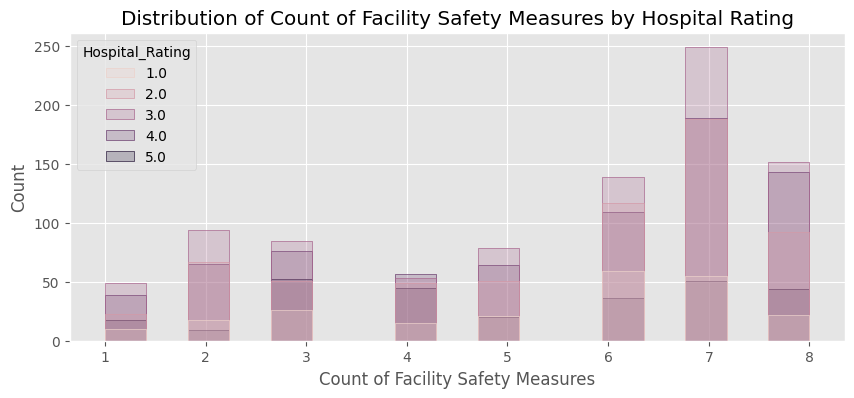

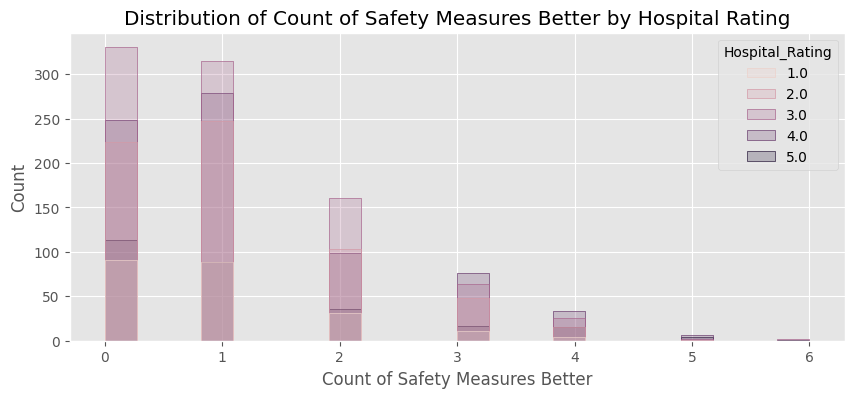

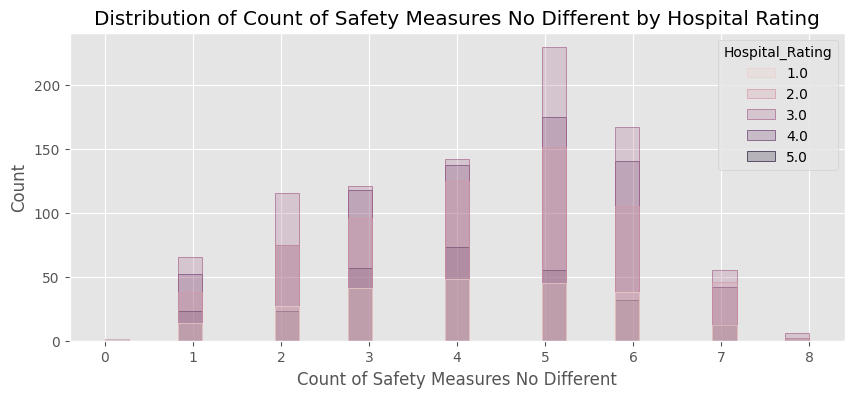

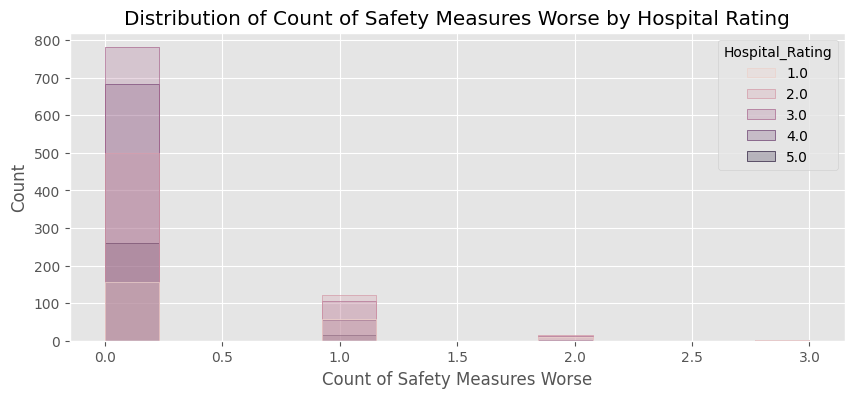

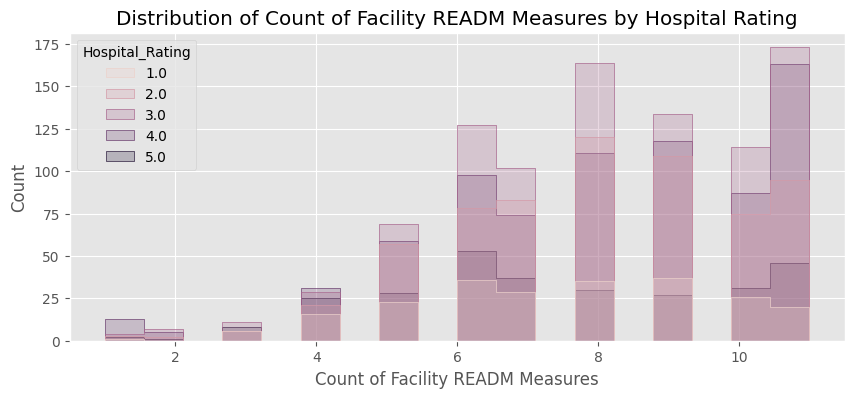

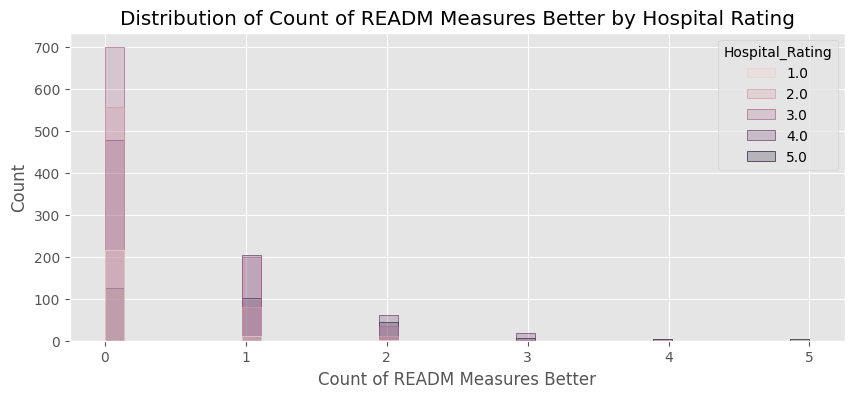

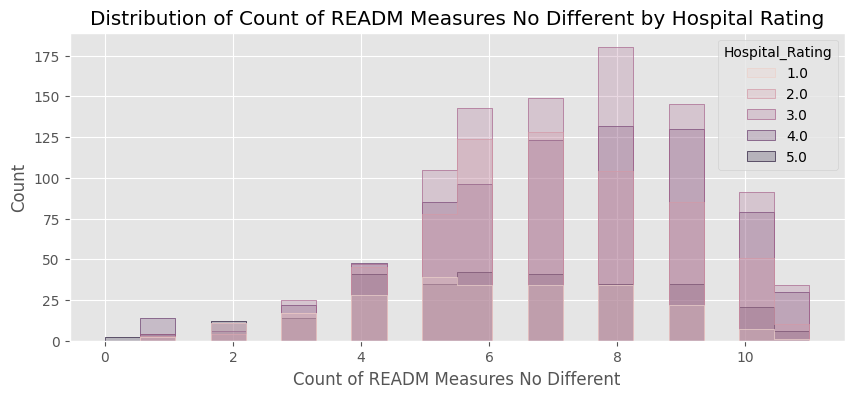

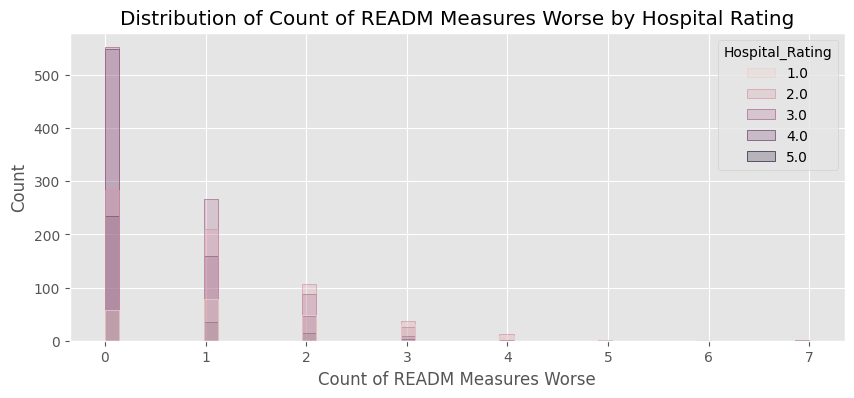

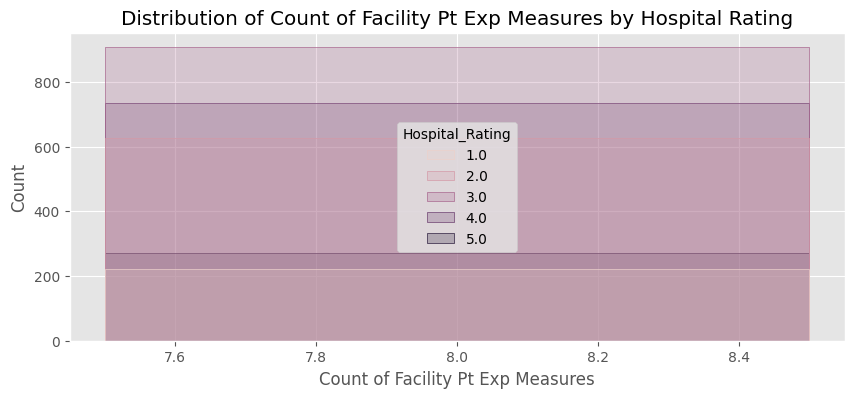

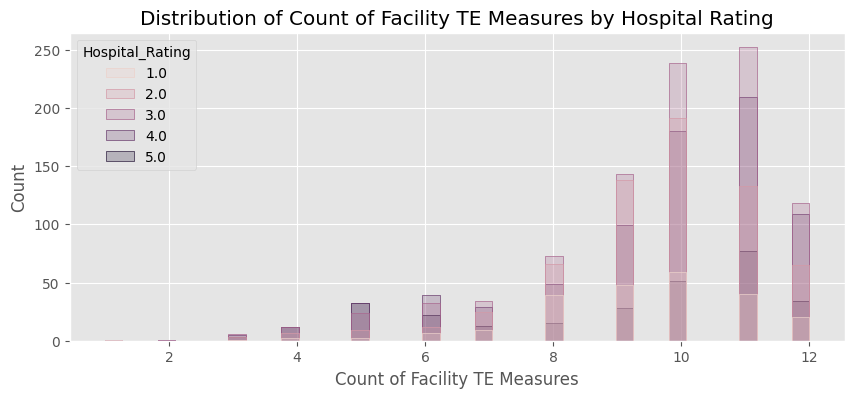

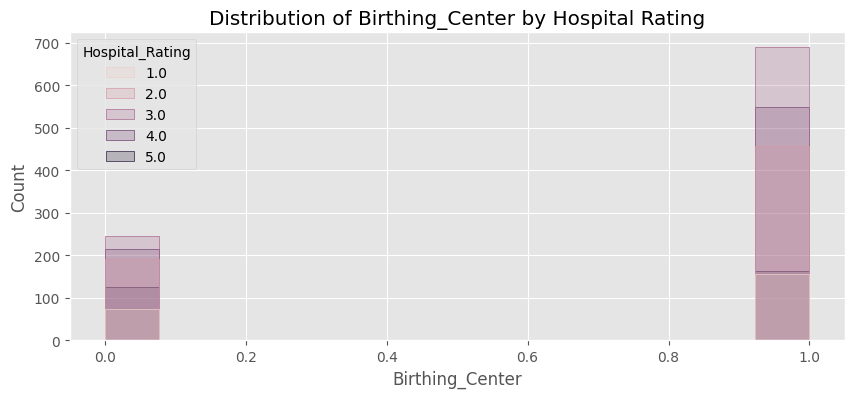

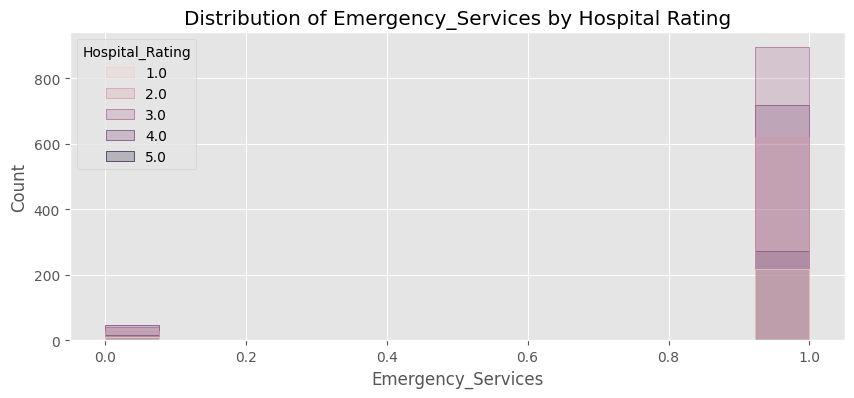

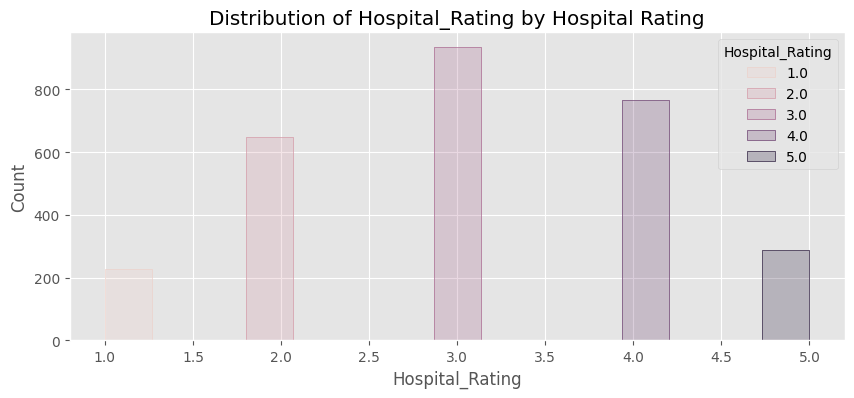

In [93]:
plt.style.use('ggplot')

for column in conf:

    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x=column, hue='Hospital_Rating', kde=False, element="step")

    plt.title(f'Distribution of {column} by Hospital Rating')
    plt.show()

# Correlation Analysis

## Correlation Heatmap

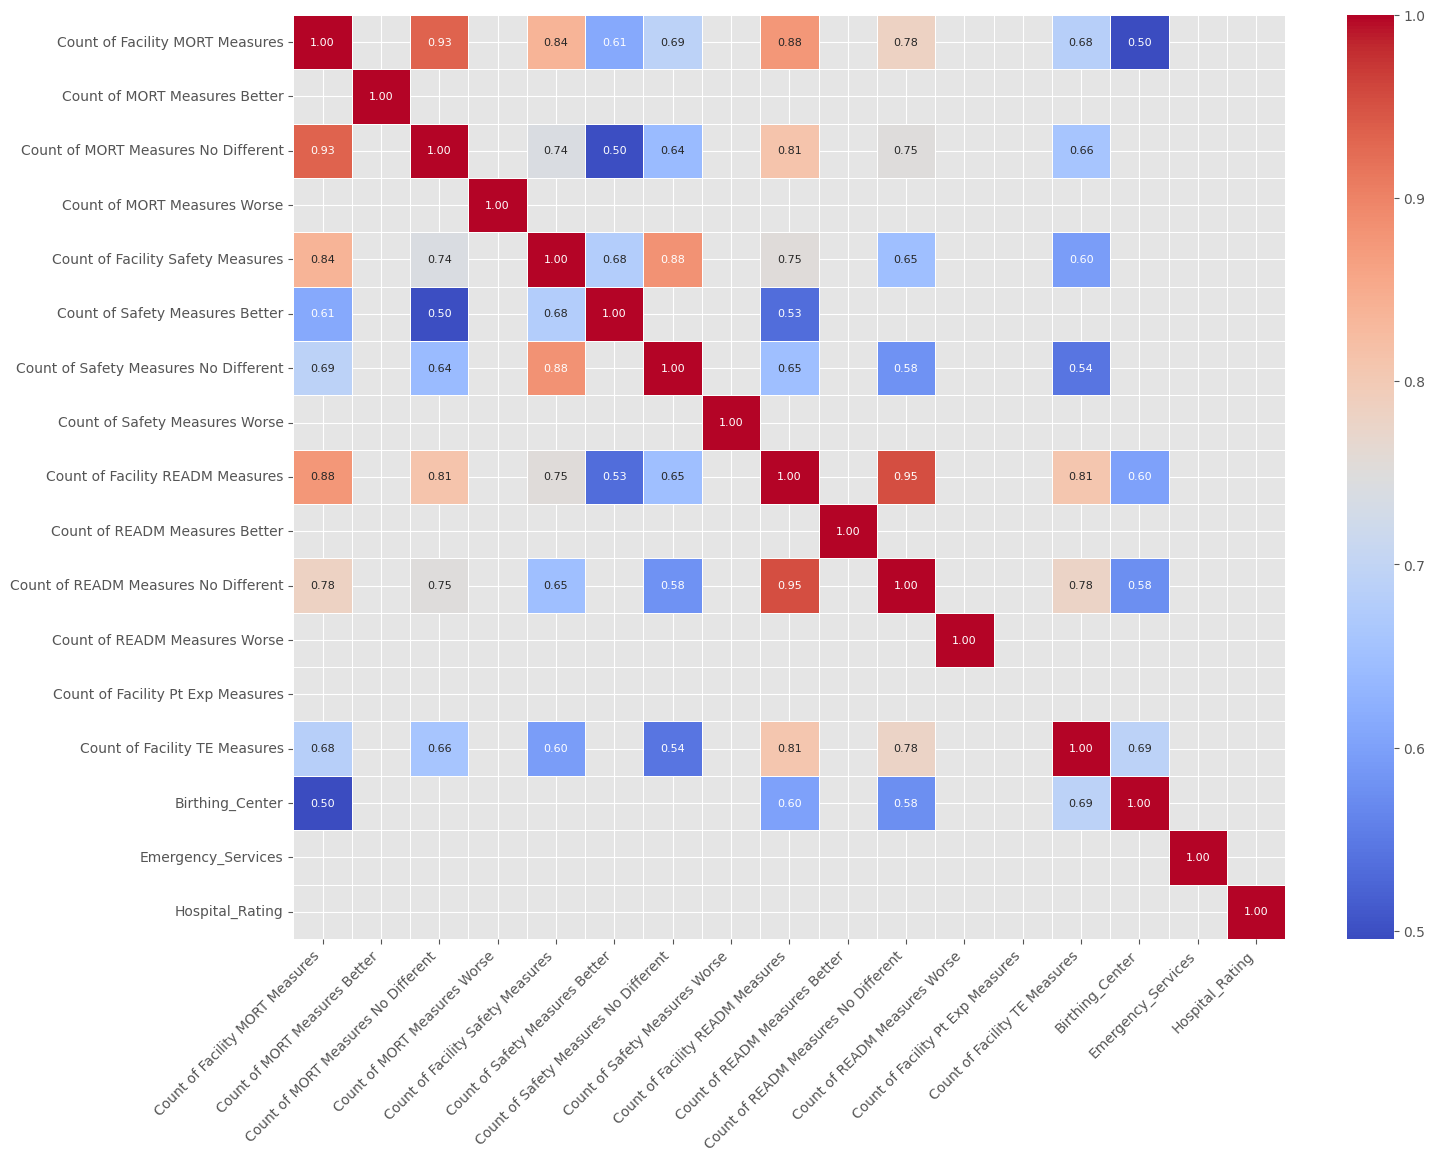

In [83]:
#significance threshold
threshold = .49
corr_matrix = df[conf].corr()
mask = abs(corr_matrix) < threshold
# Create a heatmap
plt.figure(figsize=(16, 12))
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})

# Rotate the x and y labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Show the heatmap
plt.show()

# Final Dataset

In [96]:
import os
folder_path = "Data-Folder/Hospital-Geneneral-Data/"

#save dataframe to github
file_name = "Hospital_General_Clean.csv"
df.to_csv(os.path.join(folder_path, file_name), index=False)

print(f"File saved successfully to: {folder_path}{file_name}")


File saved successfully to: Data-Folder/Hospital-Geneneral-Data/Hospital_General_Clean.csv
